# ERCS Experiment Report
## Emergency Response Coordination Simulator
### Adaptive vs Baseline Coordination Under Intermittent Connectivity

MSc Computer Science — University of Liverpool, 2026

This notebook runs the complete ERCS experiment and produces publication-quality
visualizations and statistical analysis for the dissertation.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure src is on the path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from ercs.config.parameters import AlgorithmType, SimulationConfig
from ercs.evaluation.metrics import MetricType, PerformanceEvaluator
from ercs.simulation.engine import ExperimentRunner
from ercs.visualization.plots import (
    METRICS_CONFIG,
    apply_thesis_style,
    build_anova_table,
    build_parameter_tables,
    build_results_dataframe,
    build_ttest_table,
    compute_summary_stats,
    plot_box_distributions,
    plot_degradation_lines,
    plot_grouped_bars,
    plot_heatmap,
    save_figure,
)

apply_thesis_style()
FIGURES_DIR = project_root / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Experiment Parameters

All parameters are sourced from published literature and configured
in `configs/default.yaml`.

In [2]:
config = SimulationConfig()

tables = build_parameter_tables(config)
for name, table_df in tables.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    display(table_df.style.hide(axis="index"))


  Network Topology


Parameter,Value,Source
Node count,50 (2 coordination + 48 mobile),Ullah & Qayyum (2022)
Simulation area,3000 x 1500 m²,Ullah & Qayyum (2022)
Incident zone,700 x 600 m²,Ullah & Qayyum (2022)
Radio range,100 m,Ullah & Qayyum (2022)
Buffer size,5 MB,Ullah & Qayyum (2022)
Message size,512 kB,Kumar et al. (2023)
Connectivity scenarios,"75%, 40%, 20%",Karaman et al. (2026)
Mobility model,Random Waypoint,Ullah & Qayyum (2022)
Speed range,0–20 m/s,Ullah & Qayyum (2022)



  PRoPHET Protocol


Parameter,Value,Source
P_init,0.75,Kumar et al. (2023)
β (transitivity),0.25,Kumar et al. (2023)
γ (aging),0.98,Kumar et al. (2023)
Message TTL,300 min,Ullah & Qayyum (2022)
Transmit speed,2 Mbps,Ullah & Qayyum (2022)
Buffer drop policy,Drop Oldest,Ullah & Qayyum (2022)



  Scenario Generation


Parameter,Value,Source
Task arrival,Poisson,Pu et al. (2025)
Message rate,2.0 msgs/min,Kumar et al. (2023)
Urgency distribution,20% H / 50% M / 30% L,Li et al. (2025)
Simulation duration,6000 s (100 min),Ullah & Qayyum (2022)
Runs per configuration,30,Law (2015)



  Coordination


Parameter,Value,Source
Update interval,30 min,Kaji et al. (2025)
Priority levels,3,Rosas et al. (2023)
Path threshold,P > 0.0,Ullah & Qayyum (2022)
Adaptive ordering,Urgency First,Kaji et al. (2025)
Baseline ordering,FCFS,Design decision


In [3]:
connectivity_levels = config.network.connectivity_scenarios
runs_per_config = config.scenario.runs_per_configuration

print("Experimental Design")
print("=" * 40)
print(f"  Algorithms:          2 (Adaptive, Baseline)")
print(f"  Connectivity levels: {len(connectivity_levels)} ({', '.join(f'{c*100:.0f}%' for c in connectivity_levels)})")
print(f"  Runs per config:     {runs_per_config}")
print(f"  Total runs:          {config.total_experimental_runs}")
print(f"  Sim duration:        {config.scenario.simulation_duration_seconds}s ({config.scenario.simulation_duration_seconds // 60} min)")

Experimental Design
  Algorithms:          2 (Adaptive, Baseline)
  Connectivity levels: 3 (75%, 40%, 20%)
  Runs per config:     30
  Total runs:          180
  Sim duration:        6000s (100 min)


## 2. Experiment Execution

Running all 180 simulations (2 algorithms x 3 connectivity levels x 30 runs).

> To run a quick test, change `runs_per_config` below to `5`.

In [4]:
from IPython.display import clear_output

# Change to 5 for a quick test
RUNS = runs_per_config

runner = ExperimentRunner(config=config, base_seed=42)
algorithms = [AlgorithmType.ADAPTIVE, AlgorithmType.BASELINE]
total = len(algorithms) * len(connectivity_levels) * RUNS
start_time = time.time()


def progress_callback(current, total_runs):
    clear_output(wait=True)
    pct = current / total_runs * 100
    bar_len = 40
    filled = int(bar_len * current // total_runs)
    bar = "=" * filled + ">" + " " * max(0, bar_len - filled - 1)
    elapsed = time.time() - start_time
    eta = (elapsed / current) * (total_runs - current) if current > 0 else 0

    alg_idx = (current - 1) // (len(connectivity_levels) * RUNS)
    remainder = (current - 1) % (len(connectivity_levels) * RUNS)
    conn_idx = remainder // RUNS
    run_idx = remainder % RUNS

    alg_name = algorithms[alg_idx].value.capitalize()
    conn_pct = f"{connectivity_levels[conn_idx] * 100:.0f}%"

    print(f"ERCS Experiment Progress")
    print(f"[{bar}] {current}/{total_runs} ({pct:.1f}%)")
    print(f"Current: {alg_name} @ {conn_pct} connectivity, run {run_idx + 1}/{RUNS}")
    print(f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")


results = runner.run_all(
    algorithms=algorithms,
    connectivity_levels=connectivity_levels,
    runs_per_config=RUNS,
    progress_callback=progress_callback,
)

clear_output(wait=True)
elapsed_total = time.time() - start_time
print(f"Experiment complete: {len(results)} runs in {elapsed_total:.1f}s")
print(f"Average time per run: {elapsed_total / len(results):.2f}s")

Experiment complete: 180 runs in 16.2s
Average time per run: 0.09s


In [5]:
df = build_results_dataframe(results)
print(f"Results DataFrame: {df.shape[0]} rows x {df.shape[1]} columns\n")
display(
    df.groupby(["algorithm", "connectivity"])[["delivery_rate", "assignment_rate", "avg_response_time"]]
    .describe()
    .round(4)
)

Results DataFrame: 180 rows x 12 columns



delivery_rate                                     \
                               count mean  std  min  25%  50%  75%  max   
algorithm connectivity                                                    
adaptive  0.20                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
          0.40                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
          0.75                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
baseline  0.20                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
          0.40                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
          0.75                  30.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                       assignment_rate          ...                  \
                                 count    mean  ...     75%     max   
algorithm connectivity                          ...                   
adaptive  0.20                    30.0  0.7479  ...  0.9055  0.9381   
          0.40                    30.0  0.6581  ...  0.9118  0.9326   
          0.75                    30.0  0.3561  ...  0.8756  0.9356   
baseline  0.20                    30.0  0.9002  ...  0.9153  0.9527   
          0.40                    30.0  0.9043  ...  0.9234  0.9487   
          0.75                    30.0  0.9034  ...  0.9140  0.9510   

                       avg_response_time                               \
                                   count      mean      std       min   
algorithm connectivity                                                  
adaptive  0.20                      25.0  894.1462  41.0313  821.7575   
          0.40                      22.0  896.8836  45.7591  766.4686   
          0.75                      12.0  898.6244  34.9672  841.6744   
baseline  0.20                      30.0  906.7210  27.5960  837.9163   
          0.40                      30.0  904.8930  31.3017  848.1656   
          0.75                      30.0  894.0420  36.8394  827.8940   

                                                                
                             25%       50%       75%       max  
algorithm connectivity                                          
adaptive  0.20          860.9697  899.0423  921.2455  970.2809  
          0.40          881.4352  907.1523  924.7415  964.6041  
          0.75          875.9012  892.4345  922.3719  962.7798  
baseline  0.20          892.0452  904.5626  924.0507  953.8587  
          0.40          879.1203  905.9745  919.2204  973.8846  
          0.75          867.6340  893.7099  925.6448  965.6338  

[6 rows x 24 columns]

## 3. Results Visualization

All figures use a consistent colour scheme:
- **Adaptive** (blue): Network-aware, urgency-first coordination
- **Baseline** (red): Proximity-only, FCFS coordination

In [6]:
# Precompute summary statistics for all metrics
summaries = {}
for metric_key in METRICS_CONFIG:
    summaries[metric_key] = compute_summary_stats(df, metric_key)

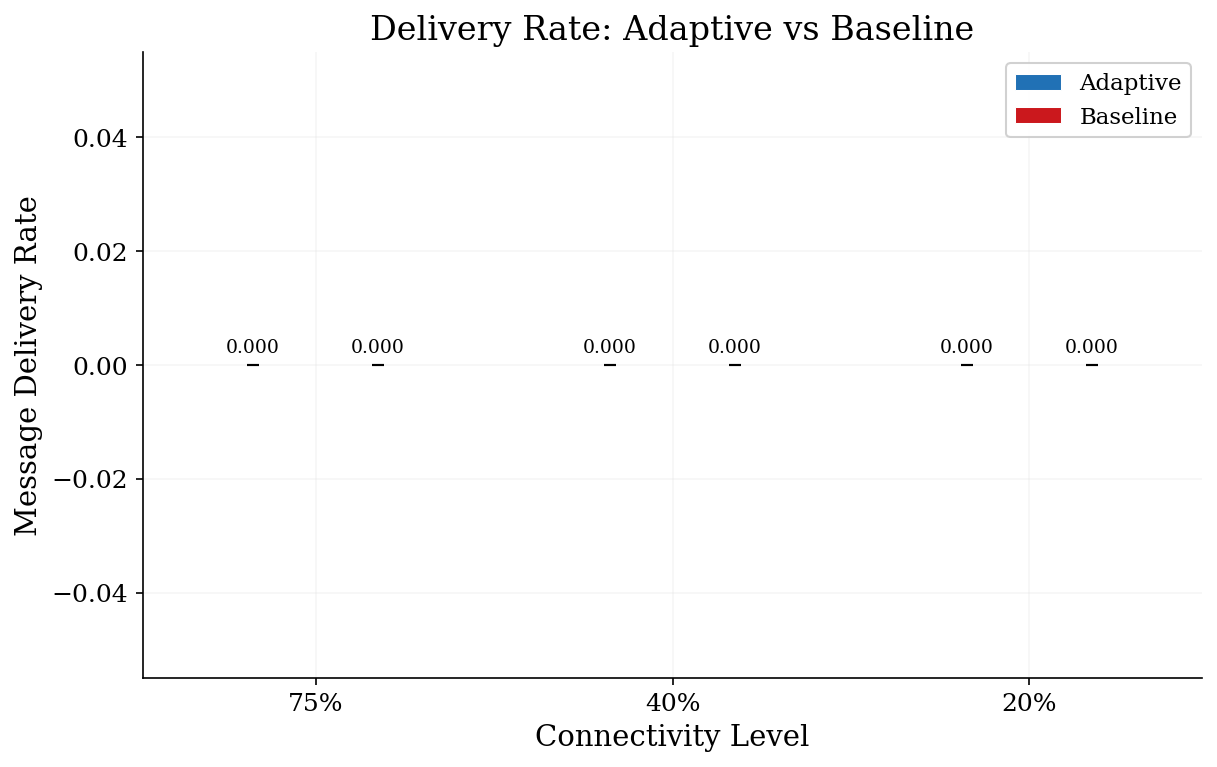

In [7]:
# Figure 1: Delivery Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["delivery_rate"], "delivery_rate")
save_figure(fig, "fig_delivery_rate_bars", FIGURES_DIR)
plt.show()

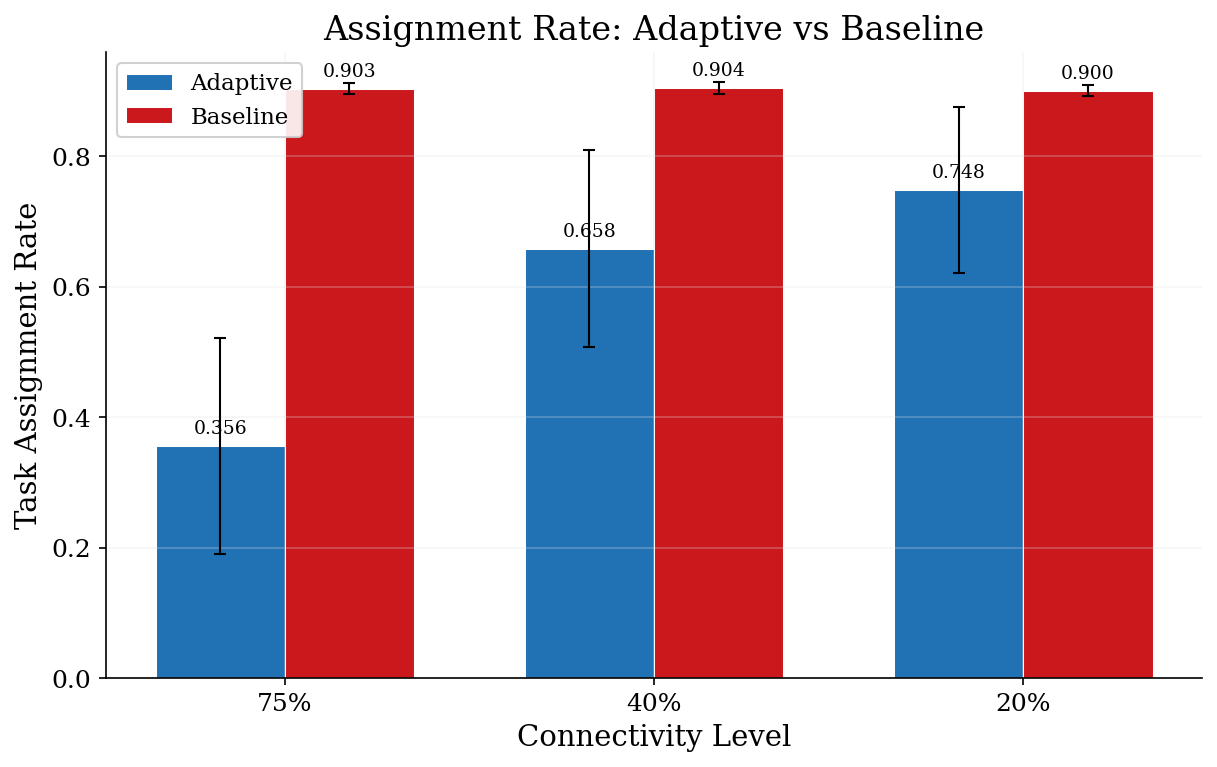

In [8]:
# Figure 2: Assignment Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["assignment_rate"], "assignment_rate")
save_figure(fig, "fig_assignment_rate_bars", FIGURES_DIR)
plt.show()

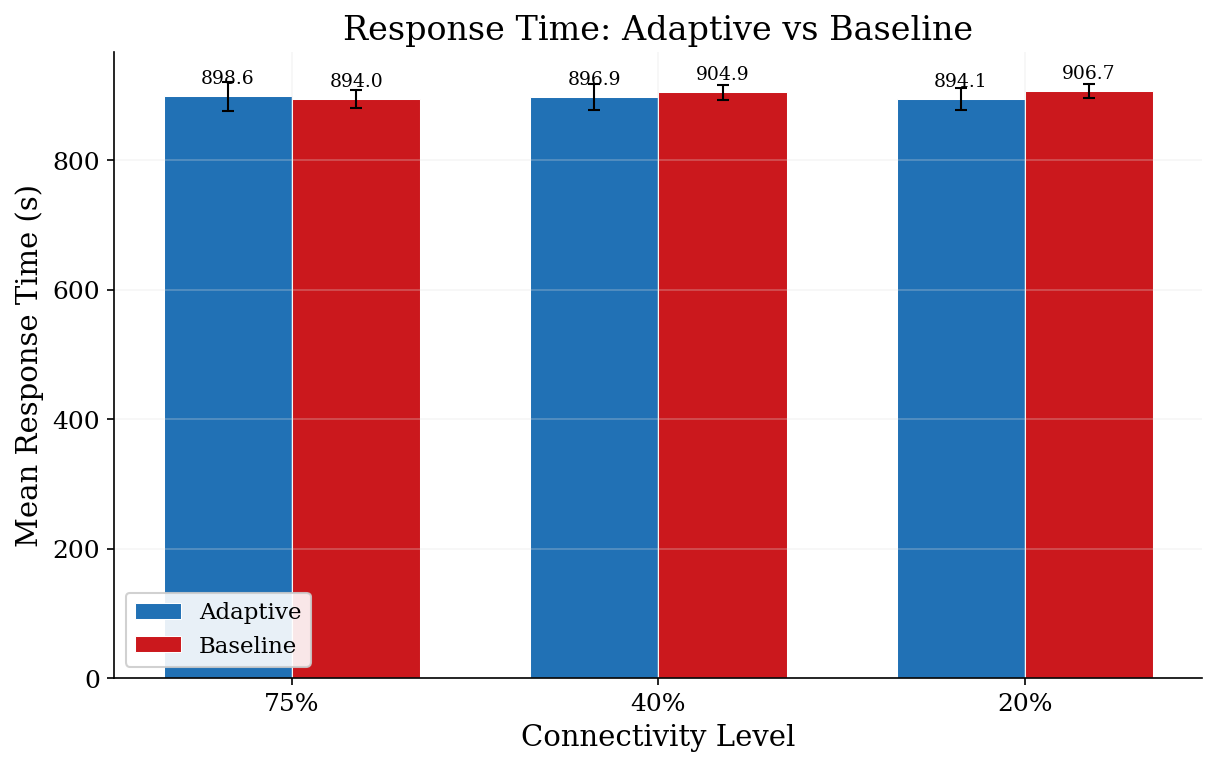

In [9]:
# Figure 3: Response Time — Grouped Bar Chart
fig = plot_grouped_bars(summaries["avg_response_time"], "avg_response_time")
save_figure(fig, "fig_response_time_bars", FIGURES_DIR)
plt.show()

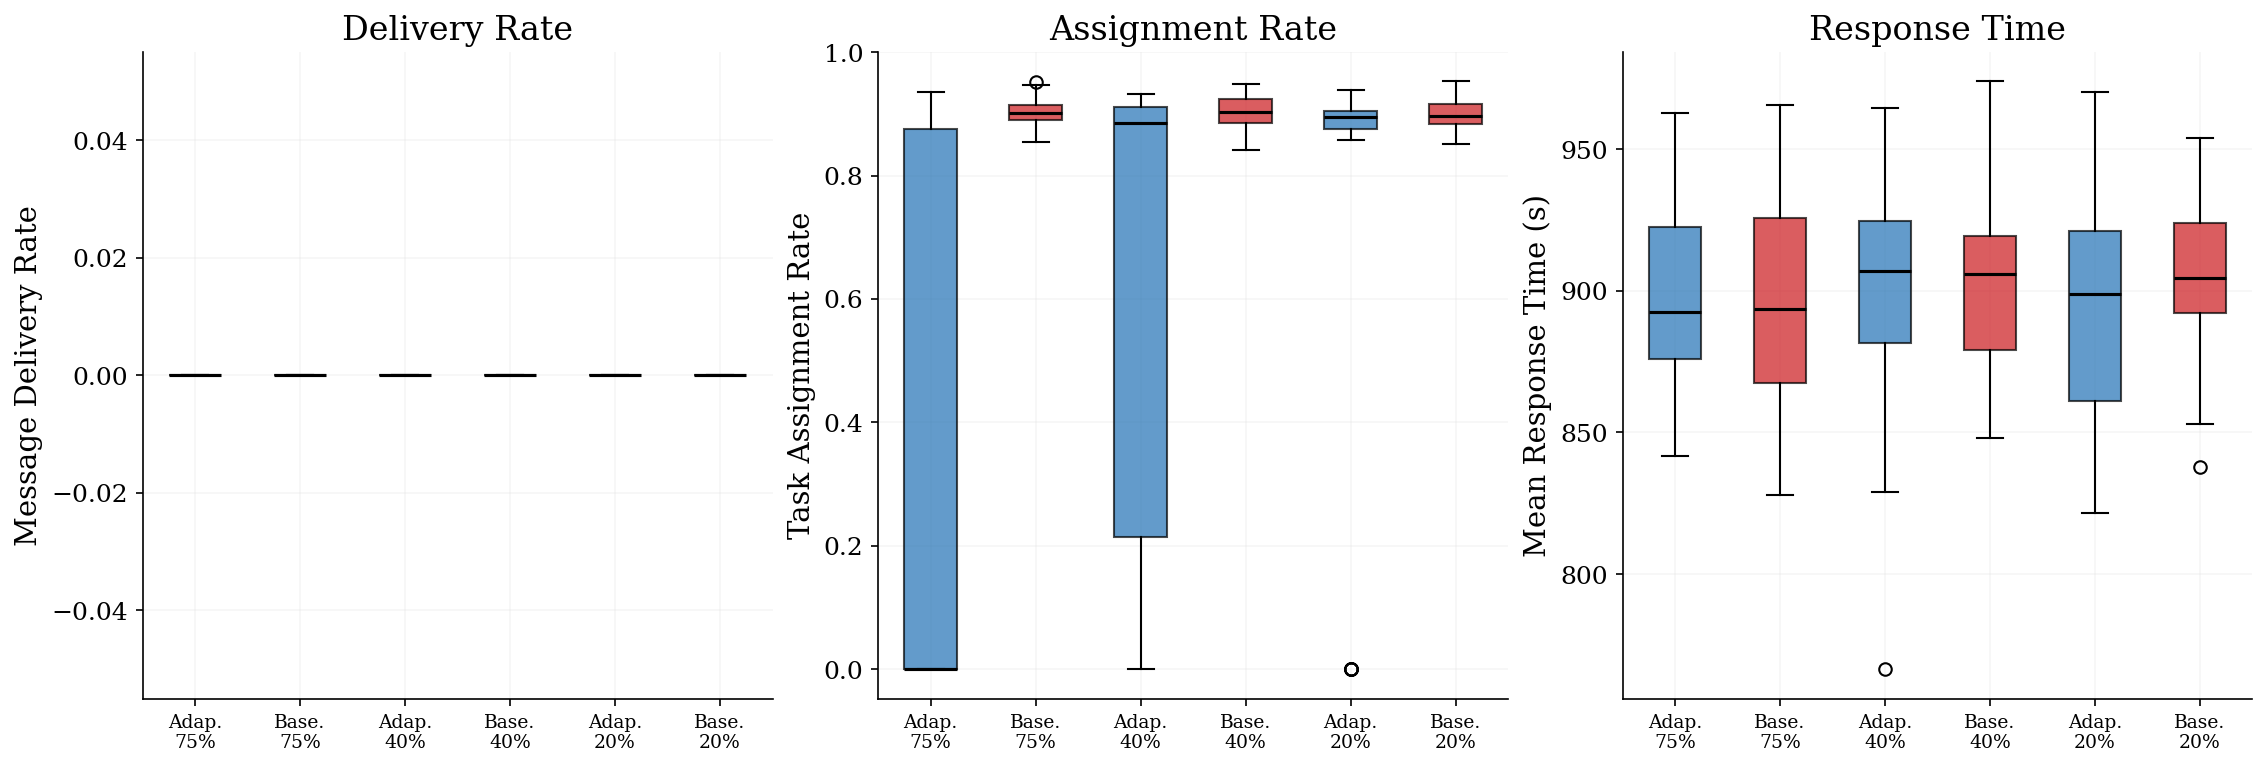

In [10]:
# Figure 4: Box Plot Distributions
fig = plot_box_distributions(df)
save_figure(fig, "fig_box_distributions", FIGURES_DIR)
plt.show()

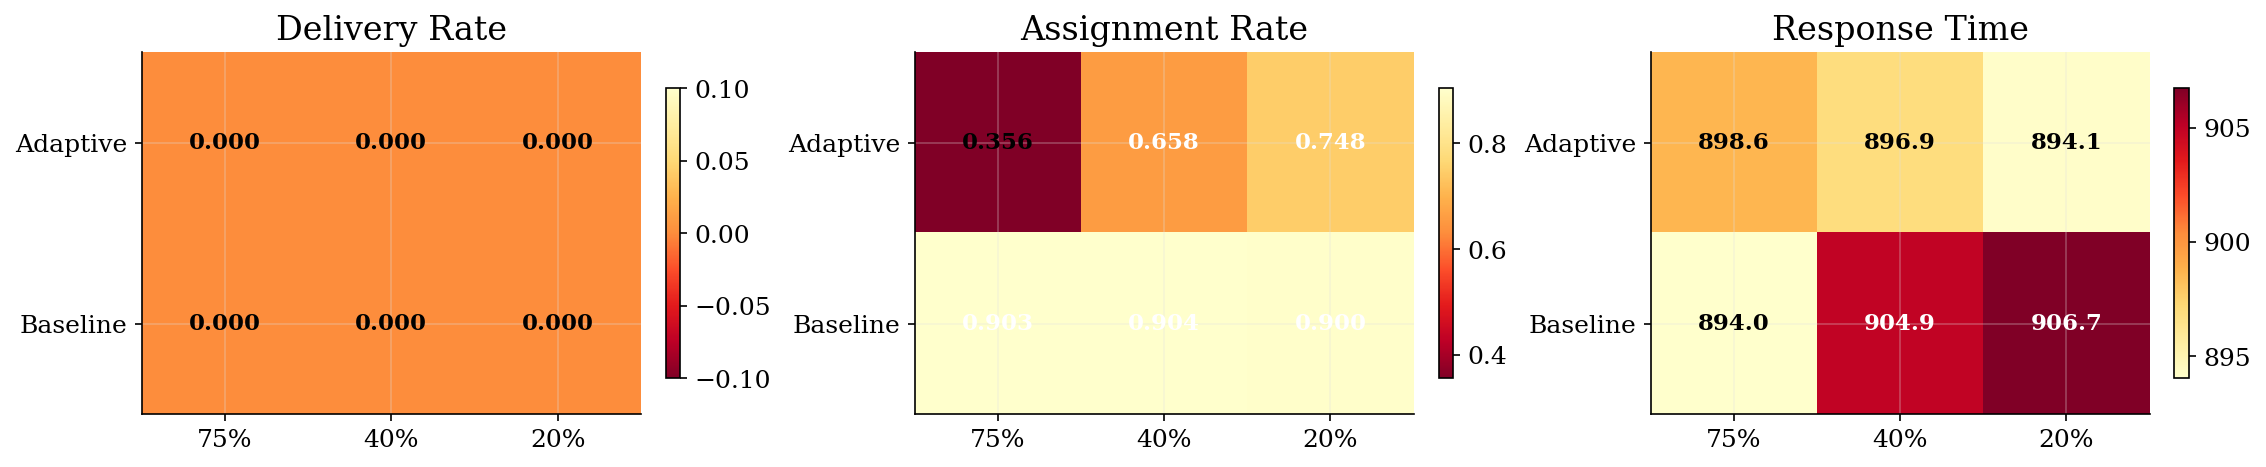

In [11]:
# Figure 5: Performance Heatmap
fig = plot_heatmap(df)
save_figure(fig, "fig_heatmap", FIGURES_DIR)
plt.show()

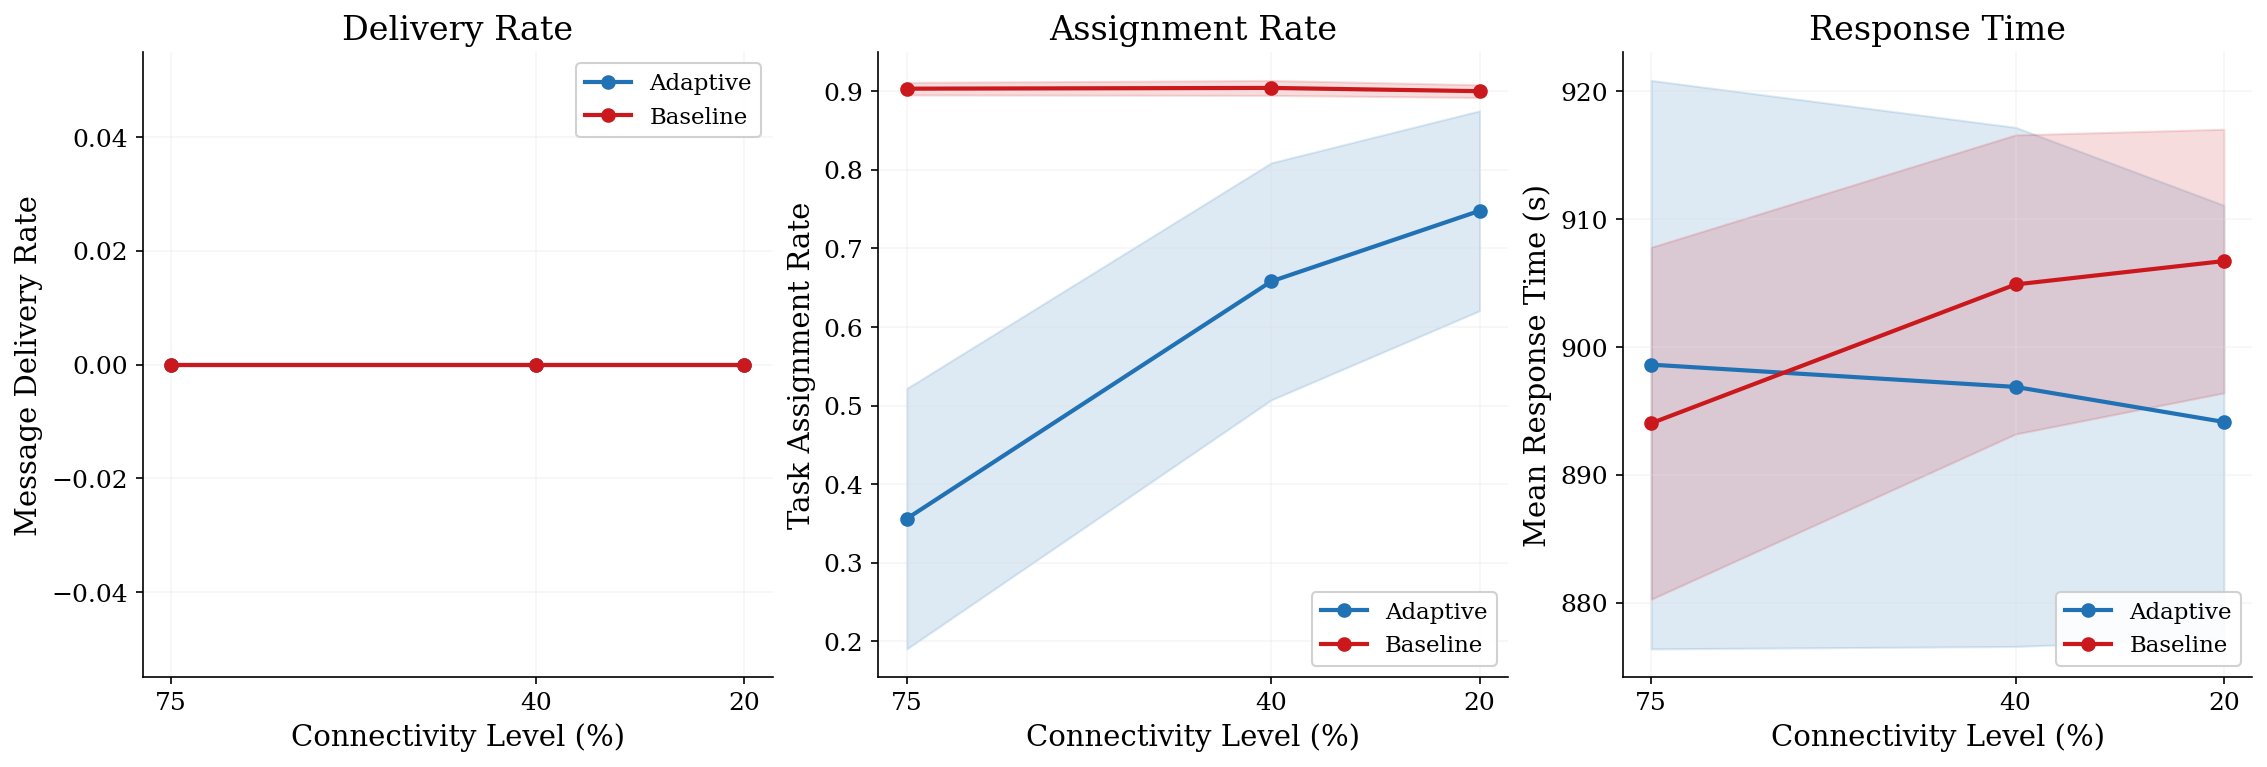

In [12]:
# Figure 6: Connectivity Degradation Lines
fig = plot_degradation_lines(summaries)
save_figure(fig, "fig_degradation_lines", FIGURES_DIR)
plt.show()

In [13]:
# Summary of saved figures
figure_files = sorted(FIGURES_DIR.glob("fig_*.png"))
print(f"\nGenerated {len(figure_files)} figures in {FIGURES_DIR}:")
for f in figure_files:
    print(f"  {f.name}")


Generated 6 figures in /Users/dianafonseca/resilient-emergency-response/outputs/figures:
  fig_assignment_rate_bars.png
  fig_box_distributions.png
  fig_degradation_lines.png
  fig_delivery_rate_bars.png
  fig_heatmap.png
  fig_response_time_bars.png


## 4. Statistical Analysis

Comparing algorithms using Welch's t-test (per connectivity level) and
one-way ANOVA (across connectivity levels). Significance level: \u03b1 = 0.05.

In [14]:
evaluator = PerformanceEvaluator(results)
report = evaluator.generate_report(
    metrics=[MetricType.DELIVERY_RATE, MetricType.ASSIGNMENT_RATE, MetricType.RESPONSE_TIME]
)

In [15]:
# Table 1: Welch's t-test Results
ttest_df = build_ttest_table(report)
display(
    ttest_df.style
    .set_caption("Table 1: Welch's t-test Results (Adaptive vs Baseline)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Connectivity,Adaptive (mean ± std),Baseline (mean ± std),Improvement,t,p-value,Cohen's d,Sig.
Delivery Rate,Overall,0.0000 ± 0.0000,0.0000 ± 0.0000,+0.00%,nan,nan,0.000,No
Delivery Rate,20%,0.0000 ± 0.0000,0.0000 ± 0.0000,+0.00%,nan,nan,0.000,No
Delivery Rate,40%,0.0000 ± 0.0000,0.0000 ± 0.0000,+0.00%,nan,nan,0.000,No
Delivery Rate,75%,0.0000 ± 0.0000,0.0000 ± 0.0000,+0.00%,nan,nan,0.000,No
Assignment Rate,Overall,0.5874 ± 0.4285,0.9026 ± 0.0227,-34.93%,-6.970,0.0000,-1.039,Yes
Assignment Rate,20%,0.7479 ± 0.3407,0.9002 ± 0.0217,-16.92%,-2.443,0.0208,-0.631,Yes
Assignment Rate,40%,0.6581 ± 0.4040,0.9043 ± 0.0255,-27.23%,-3.332,0.0023,-0.860,Yes
Assignment Rate,75%,0.3561 ± 0.4439,0.9034 ± 0.0213,-60.58%,-6.745,0.0000,-1.742,Yes
Response Time,Overall,896.0777 ± 41.1081,901.8853 ± 32.2689,-0.64%,-0.916,0.3619,-0.161,No
Response Time,20%,894.1462 ± 41.0313,906.7210 ± 27.5960,-1.39%,-1.306,0.1989,-0.366,No


In [16]:
# Table 2: ANOVA Results
anova_df = build_anova_table(report)
display(
    anova_df.style
    .set_caption("Table 2: One-way ANOVA Results (Effect of Connectivity)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Algorithm,F,p-value,df,η²,Effect,Sig.
Delivery Rate,Adaptive,nan,nan,"(2, 87)",0.000,negligible,No
Delivery Rate,Baseline,nan,nan,"(2, 87)",0.000,negligible,No
Assignment Rate,Adaptive,7.961,0.0007,"(2, 87)",0.155,large,Yes
Assignment Rate,Baseline,0.267,0.7665,"(2, 87)",0.006,negligible,No
Response Time,Adaptive,0.053,0.9484,"(2, 56)",0.002,negligible,No
Response Time,Baseline,1.364,0.2609,"(2, 87)",0.030,small,No


In [17]:
# Effect Size Interpretation
print("Effect Size Interpretation")
print("=" * 65)
for comp in report.comparisons:
    d = abs(comp.ttest.cohens_d)
    if d < 0.2:
        size = "negligible"
    elif d < 0.5:
        size = "small"
    elif d < 0.8:
        size = "medium"
    else:
        size = "large"
    if comp.connectivity_level is not None:
        label = f"{comp.metric.value} @ {comp.connectivity_level * 100:.0f}%"
    else:
        label = f"{comp.metric.value} (overall)"
    sig = "*" if comp.ttest.significant else ""
    print(f"  {label:40s}  d = {comp.ttest.cohens_d:+.3f} ({size}){sig}")

Effect Size Interpretation
  delivery_rate (overall)                   d = +0.000 (negligible)
  delivery_rate @ 20%                       d = +0.000 (negligible)
  delivery_rate @ 40%                       d = +0.000 (negligible)
  delivery_rate @ 75%                       d = +0.000 (negligible)
  assignment_rate (overall)                 d = -1.039 (large)*
  assignment_rate @ 20%                     d = -0.631 (medium)*
  assignment_rate @ 40%                     d = -0.860 (large)*
  assignment_rate @ 75%                     d = -1.742 (large)*
  response_time (overall)                   d = -0.161 (negligible)
  response_time @ 20%                       d = -0.366 (small)
  response_time @ 40%                       d = -0.211 (small)
  response_time @ 75%                       d = +0.126 (negligible)


## 5. Key Findings

In [18]:
print("KEY FINDINGS")
print("=" * 60)

# 1. Overall delivery rate
overall_dr = next(
    (c for c in report.comparisons
     if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is None),
    None,
)
if overall_dr:
    print(f"\n1. DELIVERY RATE (Overall)")
    print(f"   Adaptive: {overall_dr.adaptive_stats.mean:.4f} +/- {overall_dr.adaptive_stats.std:.4f}")
    print(f"   Baseline: {overall_dr.baseline_stats.mean:.4f} +/- {overall_dr.baseline_stats.std:.4f}")
    print(f"   Improvement: {overall_dr.improvement:+.2f}%")
    print(f"   Significant: {'Yes' if overall_dr.ttest.significant else 'No'} (p={overall_dr.ttest.p_value:.4f})")

# 2. Where advantage is largest
per_conn = [
    c for c in report.comparisons
    if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is not None
]
if per_conn:
    best = max(per_conn, key=lambda c: c.improvement)
    print(f"\n2. LARGEST ADAPTIVE ADVANTAGE")
    print(f"   At {best.connectivity_level * 100:.0f}% connectivity: {best.improvement:+.2f}% improvement")

# 3. Connectivity effect
print(f"\n3. CONNECTIVITY EFFECT (ANOVA)")
for key, anova in report.anova_results.items():
    parts = key.rsplit("_", 1)
    metric_name = parts[0].replace("_", " ").title()
    algorithm = parts[1].capitalize() if len(parts) > 1 else "All"
    print(
        f"   {metric_name} ({algorithm}): "
        f"F({anova.df_between},{anova.df_within}) = {anova.f_statistic:.3f}, "
        f"p = {anova.p_value:.4f}, \u03b7\u00b2 = {anova.eta_squared:.3f}"
    )

print("\n" + "=" * 60)
print(f"Experiment complete. All figures saved to: {FIGURES_DIR}")

KEY FINDINGS

1. DELIVERY RATE (Overall)
   Adaptive: 0.0000 +/- 0.0000
   Baseline: 0.0000 +/- 0.0000
   Improvement: +0.00%
   Significant: No (p=nan)

2. LARGEST ADAPTIVE ADVANTAGE
   At 20% connectivity: +0.00% improvement

3. CONNECTIVITY EFFECT (ANOVA)
   Delivery Rate (Adaptive): F(2,87) = nan, p = nan, η² = 0.000
   Delivery Rate (Baseline): F(2,87) = nan, p = nan, η² = 0.000
   Assignment Rate (Adaptive): F(2,87) = 7.961, p = 0.0007, η² = 0.155
   Assignment Rate (Baseline): F(2,87) = 0.267, p = 0.7665, η² = 0.006
   Response Time (Adaptive): F(2,56) = 0.053, p = 0.9484, η² = 0.002
   Response Time (Baseline): F(2,87) = 1.364, p = 0.2609, η² = 0.030

Experiment complete. All figures saved to: /Users/dianafonseca/resilient-emergency-response/outputs/figures
